# N2 · rectified flow: reflow 拉直路径 (Rectified Flow)

> 配套 13.2-L2 · 对比 flow matching 直接采样 vs 一轮 reflow 后采样: reflow 后用更少步达同等质量,
> 亲手验证「拉直路径 = 省步」。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import flow_matching as fm
print('就绪')

就绪


## 1. 第一轮 flow matching (路径还弯, L2)

In [2]:
torch.manual_seed(0)
x1 = fm.make_two_moons(n=512, seed=1)
m1 = fm.build_velocity_field(); fm.train_flow_matching(m1, x1, epochs=500)
q1 = fm.quality_vs_steps(m1, x1, step_list=(2,4,8))
print("reflow 前, 少步质量:")
for r in q1: print(f"  {r['steps']} 步: std_err {r['std_err']}")

reflow 前, 少步质量:
  2 步: std_err 0.5221
  4 步: std_err 0.2427
  8 步: std_err 0.118


## 2. reflow (重流): 用模型自己的配对重训, 拉直路径 (L2)

In [3]:
m2, losses2 = fm.reflow(m1, x1, epochs=500)
q2 = fm.quality_vs_steps(m2, x1, step_list=(2,4,8))
print("reflow 后, 少步质量:")
for r in q2: print(f"  {r['steps']} 步: std_err {r['std_err']}")
print("\n→ reflow 后, 同样步数质量更好 (路径更直 = 少步够用)。")

reflow 后, 少步质量:
  2 步: std_err 0.0556
  4 步: std_err 0.0531
  8 步: std_err 0.0521

→ reflow 后, 同样步数质量更好 (路径更直 = 少步够用)。


## 3. 对比图: reflow 前后, 少步质量

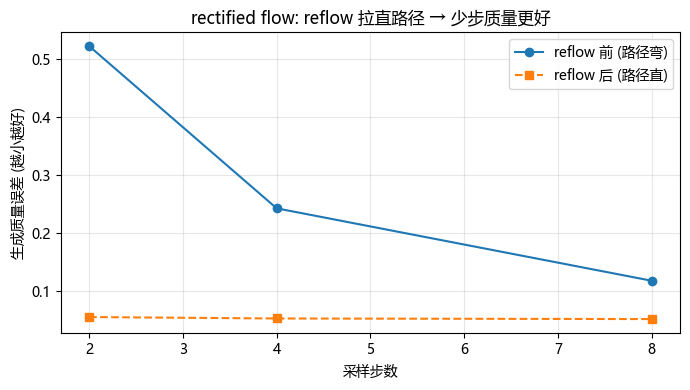

→ 这就是 rectified flow: 拉直路径让 1-4 步生成成为可能 (L2)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
steps = [r['steps'] for r in q1]
plt.figure(figsize=(7,4))
plt.plot(steps, [r['std_err'] for r in q1], 'o-', label='reflow 前 (路径弯)')
plt.plot(steps, [r['std_err'] for r in q2], 's--', label='reflow 后 (路径直)')
plt.xlabel('采样步数'); plt.ylabel('生成质量误差 (越小越好)')
plt.title('rectified flow: reflow 拉直路径 → 少步质量更好'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("→ 这就是 rectified flow: 拉直路径让 1-4 步生成成为可能 (L2)。")

## 4. 反思 (13.2 收口)

你亲手验证了「拉直路径 = 省步」: reflow 后同样步数质量明显更好。带走:
- 采样步数本质是「跟住路径弯曲」的代价; 路径越直步数越少 (L2)。
- rectified flow (reflow) / consistency (一步映射, L3) 都逼近一步生成 = 扩散质量 + GAN 速度。
- 速度是实时 omni (M10.5) / 机器人控制 (M11.3) 落地的命门。

> **M13.2 收口**: 扩散从上千步压到 1-4 步。
> 交棒 13.3: 扩散的「骨架」用什么网络? 答案是 **DiT (Diffusion Transformer)** —— 把 U-Net 换成
> transformer (你的本行!) + latent diffusion + classifier-free guidance。下一专题 `dit-latent-diffusion`。